In [2]:
import tensorflow as tf
import numpy as np
import json
import h5py

classification_model = tf.keras.models.load_model("../models/resnet_finetuned.h5", compile=False)
dual_model = tf.keras.models.load_model("../models/resnet_dual_finetuned.h5", compile=False)

with open("../data/processed/category_mapping.json") as f:
    mapping = json.load(f)

print("Models loaded successfully")
print("Categories:", mapping["int_to_category"])

Models loaded successfully
Categories: {'0': 'Cyclonic Storm', '1': 'Deep Depression', '2': 'Depression', '3': 'Extremely Severe / Super Cyclone', '4': 'Severe Cyclonic Storm', '5': 'Very Severe Cyclonic Storm'}


In [3]:
import pandas as pd

summary = pd.DataFrame({
    "Model": ["Baseline CNN", "ResNet50 (Transfer Learning, Fine-tuned)", "Dual-Head (Classification + Regression)"],
    "Test Accuracy": ["79%", "88.27%", "88.27% (classification)"],
    "Additional Metric": ["-", "-", "Regression MAE ≈ 21 knots"]
})
print(summary.to_string(index=False))
summary.to_csv("../outputs/evaluation_reports/final_summary.csv", index=False)

                                   Model           Test Accuracy         Additional Metric
                            Baseline CNN                     79%                         -
ResNet50 (Transfer Learning, Fine-tuned)                  88.27%                         -
 Dual-Head (Classification + Regression) 88.27% (classification) Regression MAE ≈ 21 knots


In [4]:
import h5py

class CycloneDataGeneratorTL(tf.keras.utils.Sequence):
    def __init__(self, h5_path, indices, labels, batch_size=32, shuffle=True):
        self.h5_path = h5_path
        self.indices = indices
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return len(self.indices) // self.batch_size

    def __getitem__(self, idx):
        batch_indices = self.indices[idx*self.batch_size : (idx+1)*self.batch_size]
        batch_indices_sorted = np.sort(batch_indices)

        with h5py.File(self.h5_path, 'r') as f:
            images = f['Images'][batch_indices_sorted].astype('float32')

        images = images[:, :, :, :3]
        images = tf.image.resize(images, (224, 224))
        images = tf.keras.applications.resnet50.preprocess_input(images)

        labels = self.labels[batch_indices_sorted]
        return images, labels

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [5]:
h5_path = "../data/raw/TheCycloneImageDataset/Cyclone_Images.h5"
test_idx = np.load("../data/processed/test_idx.npy")
encoded_labels = np.load("../data/processed/encoded_labels.npy")

test_gen = CycloneDataGeneratorTL(h5_path, test_idx, encoded_labels, batch_size=32, shuffle=False)
print("Test batches:", len(test_gen))

Test batches: 98


In [6]:
test_preds = classification_model.predict(test_gen)
test_pred_classes = np.argmax(test_preds, axis=1)

# True labels EXACTLY usi order me nikaalo jis order me generator deta hai
true_labels = []
for i in range(len(test_gen)):
    _, batch_labels = test_gen[i]
    true_labels.extend(batch_labels)
true_labels = np.array(true_labels)

print("Predictions shape:", test_pred_classes.shape)
print("True labels shape:", true_labels.shape)

/Users/chessinorbit/Desktop/CYCLONE-PREDICTION/venv/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2026-09-04 13:37:34.188017: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


98/98 ━━━━━━━━━━━━━━━━━━━━ 22s 216ms/step
Predictions shape: (3136,)
True labels shape: (3136,)


                                  precision    recall  f1-score   support

                  Cyclonic Storm       0.77      0.78      0.78       483
                 Deep Depression       0.73      0.75      0.74       680
                      Depression       0.88      0.88      0.88      1133
Extremely Severe / Super Cyclone       0.93      0.89      0.91       129
           Severe Cyclonic Storm       0.82      0.80      0.81       400
      Very Severe Cyclonic Storm       0.86      0.86      0.86       311

                        accuracy                           0.82      3136
                       macro avg       0.83      0.83      0.83      3136
                    weighted avg       0.83      0.82      0.83      3136



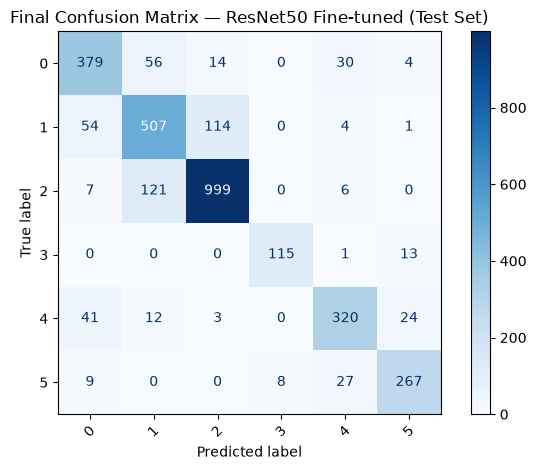

In [7]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

category_names = [mapping["int_to_category"][str(i)] for i in range(len(mapping["int_to_category"]))]

print(classification_report(true_labels, test_pred_classes, target_names=category_names))

cm = confusion_matrix(true_labels, test_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(len(category_names)))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Final Confusion Matrix — ResNet50 Fine-tuned (Test Set)")
plt.tight_layout()
plt.savefig("../outputs/evaluation_reports/final_confusion_matrix.png", dpi=150)
plt.show()